In [1]:
import torch
import torch.nn as nn
import numpy as np
import sys
import os
import json
import itertools
import pandas as pd
import gc
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# Referencing your project structure verbatim
sys.path.append(os.path.abspath(".."))
from src.architectures import GeneralMLP # Verbatim reference to architectures.py
from src.utils import set_seed, apply_heavy_tailed_init # Verbatim reference to utils.py
from src.continual_learning import apply_GPM_projection, update_GPM_bases

def save_physics_snapshot(model, input_batch, output_dir, t_idx, epoch, alpha, g):
    model.eval()

    # Capture pre-activations
    pre_acts = model.get_pre_activations(input_batch)
    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]

    layer_physics = {}
    for idx, layer in enumerate(linear_layers):
        layer_key = f"layer_{idx}" if idx < len(linear_layers) - 1 else "classifier"
        # Extract pre-activation for this specific layer
        h = pre_acts[idx] if idx < len(linear_layers) - 1 else pre_acts["classifier"]

        layer_physics[layer_key] = {
            "pre_activations": h.float().cpu()
        }

    snapshot = {
        "metadata": {"task": t_idx + 1, "epoch": epoch, "alpha": alpha, "g": g},
        "state_dict": model.state_dict(), # Weights W are stored here
        "physics_data": layer_physics    # Only storing h to save space
    }

    output_dir.mkdir(parents=True, exist_ok=True)
    file_path = output_dir / f"snapshot_T{t_idx+1}_E{epoch}.pt"

    # Using weights + pre_acts allows reconstruction of J, Rank, and CKA later
    torch.save(snapshot, file_path)
    return file_path

In [15]:
# --- 1. CONFIGURATION ---
num_tasks = 5  # Standard for Split Fashion-MNIST (2 classes per task)
seeds = [7, 8, 9, 10, 11, 12, 13, 14, 15, 16]  # Multiple seeds for robustness
alpha_list = [1.2, 2.0]
g_list = [1.0]
depth = 9
hidden_size = 784
bias = False
activation_name = "tanh"
optimiser = "sgd"
batch_size = 128
lr = 1e-2
epochs = 20
snapshot_epochs = [19]
GPM_THRESHOLD = 0.97

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 2. DATA LOADING & SPLITTING ---
def get_split_tasks(dataset, num_tasks=5, seed=0):
    """
    Filters dataset into subsets of 2 classes per task.
    Shuffles the class order deterministically based on the provided run seed.
    """
    imgs = torch.stack([img for img, _ in dataset]).to(device).view(-1, 784)
    lbls = torch.tensor([lbl for _, lbl in dataset]).to(device)

    # 1. Generate a deterministic permutation of all 10 classes unique to this seed
    # FIX: Force the generator to reside on the CPU
    generator = torch.Generator(device='cpu').manual_seed(seed)

    # Generate on CPU first, THEN push the resulting 10-element tensor to CUDA
    shuffled_classes = torch.randperm(10, generator=generator).to(device)

    task_bundles = []
    # 2. Extract pairs from the shuffled class array
    for i in range(num_tasks):
        c1 = shuffled_classes[2 * i]
        c2 = shuffled_classes[2 * i + 1]

        mask = (lbls == c1) | (lbls == c2)
        task_bundles.append((imgs[mask], lbls[mask]))

    return task_bundles

print("Fast-loading Fashion-MNIST to GPU and splitting by class...")
f_train = datasets.FashionMNIST('../data', train=True, download=True, transform=transforms.ToTensor())
f_test = datasets.FashionMNIST('../data', train=False, download=True, transform=transforms.ToTensor())

# --- 3. GRID SWEEP EXECUTION ---
for seed in seeds:
    print(f"\n=== Starting experiments for seed {seed} ===")
    # Pre-split the data into 5 tasks
    train_tasks = get_split_tasks(f_train, num_tasks, seed=seed)
    test_tasks = get_split_tasks(f_test, num_tasks, seed=seed)
    for alpha, g in itertools.product(alpha_list, g_list):
        set_seed(seed) # Assuming your set_seed function is defined globally
        run_name = f"decay_alpha_{alpha}_g_{g}_lr_{lr}_s{seed}"
        output_dir = Path(f"./fashion_gpm{GPM_THRESHOLD}_fc{depth+1}/{run_name}")
        output_dir.mkdir(parents=True, exist_ok=True)

        # Metadata Logging
        config_params = {
            "alpha": alpha, "g": g, "seed": seed, "depth": depth,
            "hidden_size": hidden_size, "lr": lr, "batch_size": batch_size,
            "activation": activation_name, "num_tasks": num_tasks,
            "snapshot_epochs": snapshot_epochs, "bias": bias,
            "scenario": "Split Fashion-MNIST"
        }
        with open(output_dir / f"run_config_seed_{seed}.json", "w") as f:
            json.dump(config_params, f, indent=4)

        # Note: Ensure GeneralMLP and apply_heavy_tailed_init are available in your scope
        model = GeneralMLP(784, hidden_size, 10, depth, activation_name, bias=bias).to(device)
        apply_heavy_tailed_init(model, alpha=alpha, g=g, base_seed=seed)

        # 1. CACHE THE LAYERS ONCE
        linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]

        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
        criterion = torch.nn.CrossEntropyLoss()
        results_history = []
        gpm_feature_bases = None

        for t_idx in range(num_tasks):
            # --- NEW: Task-Wise LR Adjustment ---
            # We keep the initial LR for Task 1, then decay for subsequent tasks
            current_lr = lr if t_idx == 0 else lr * 0.02  # Example: 10x decay after Task 1

            for param_group in optimizer.param_groups:
                param_group['lr'] = current_lr

            print(f"\n[{run_name}] --- Task {t_idx + 1} (LR: {current_lr}) ---")
            # ------------------------------------
            curr_train_imgs, curr_train_lbls = train_tasks[t_idx]
            train_loader = DataLoader(TensorDataset(curr_train_imgs, curr_train_lbls),
                                    batch_size=batch_size, shuffle=True)

            for epoch in range(epochs):
                model.train()
                total_train_loss, train_correct, train_total = 0, 0, 0
                for inputs, labels in train_loader:
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    loss.backward()

                    if t_idx == 0:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=50.0)

                    # --- NEW: GPM PROJECTION STEP ---
                    if t_idx > 0:
                        apply_GPM_projection(linear_layers, gpm_feature_bases)

                    optimizer.step()

                    total_train_loss += loss.item()
                    train_correct += (outputs.argmax(1) == labels).sum().item()
                    train_total += labels.size(0)

                # Snapshot saving (Capturing first batch of current task)
                if epoch in snapshot_epochs:
                    save_physics_snapshot(model, curr_train_imgs[:batch_size],
                                        output_dir / "checkpoints", t_idx, epoch, alpha, g)

                # Evaluation phase: Check current and all previous tasks
                model.eval()
                epoch_metrics = {
                    "alpha": alpha, "g": g, "epoch": epoch + 1, "task_id": t_idx + 1,
                    "train_loss": total_train_loss / len(train_loader),
                    "train_acc": train_correct / train_total,
                }

                # Pre-fill columns for all possible 5 tasks
                for i in range(num_tasks):
                    epoch_metrics[f"task_{i+1}_acc"] = np.nan

                with torch.no_grad():
                    for prev_t_idx in range(t_idx + 1):
                        val_imgs, val_lbls = test_tasks[prev_t_idx]
                        outputs = model(val_imgs)
                        acc = (outputs.argmax(1) == val_lbls).float().mean().item()
                        epoch_metrics[f"task_{prev_t_idx+1}_acc"] = acc

                results_history.append(epoch_metrics)

                # Live tracking printout
                print(f"Ep {epoch+1:02d} | T1: {epoch_metrics['task_1_acc']:.4f} | "
                   f"Curr: {epoch_metrics[f'task_{t_idx+1}_acc']:.4f} | Loss: {epoch_metrics['train_loss']:.4f}")

            # --- AFTER TASK COMPLETION: UPDATE GPM MEMORY ---
            print(f"Updating GPM memory for Task {t_idx+1}...")
            # Use a small subset (e.g., 300 samples) of the current task for SVD
            svd_samples = curr_train_imgs[:300]
            gpm_feature_bases, task_ranks = update_GPM_bases(model, svd_samples, GPM_THRESHOLD, gpm_feature_bases)

            if results_history:
                for i, r in enumerate(task_ranks):
                    results_history[-1][f"layer_{i}_rank"] = r

                # Also log a "Total Capacity" metric (sum of ranks across layers)
                results_history[-1]["total_rank_sum"] = sum(task_ranks)

            # Printout for immediate feedback
            for i, r in enumerate(task_ranks):
                print(f"  Layer {i} Rank: {r}")

        # Save and Cleanup
        df = pd.DataFrame(results_history)
        df.to_csv(output_dir / f"results_log_seed_{seed}.csv", index=False)

        del model, optimizer, results_history, df
        torch.cuda.empty_cache()
        gc.collect()

Fast-loading Fashion-MNIST to GPU and splitting by class...

=== Starting experiments for seed 7 ===
Applying HT Init: alpha=1.2, g=1.0, seed=7

[decay_alpha_1.2_g_1.0_lr_0.01_s7] --- Task 1 (LR: 0.01) ---
Ep 01 | T1: 0.9980 | Curr: 0.9980 | Loss: 3.4464
Ep 02 | T1: 0.9980 | Curr: 0.9980 | Loss: 0.5339
Ep 03 | T1: 0.9970 | Curr: 0.9970 | Loss: 0.3365
Ep 04 | T1: 0.9970 | Curr: 0.9970 | Loss: 0.2455
Ep 05 | T1: 0.9985 | Curr: 0.9985 | Loss: 0.1681
Ep 06 | T1: 0.9985 | Curr: 0.9985 | Loss: 0.1773
Ep 07 | T1: 0.9985 | Curr: 0.9985 | Loss: 0.0794
Ep 08 | T1: 0.9975 | Curr: 0.9975 | Loss: 0.0828
Ep 09 | T1: 0.9985 | Curr: 0.9985 | Loss: 0.0535
Ep 10 | T1: 0.9980 | Curr: 0.9980 | Loss: 0.0389
Ep 11 | T1: 0.9985 | Curr: 0.9985 | Loss: 0.0296
Ep 12 | T1: 0.9980 | Curr: 0.9980 | Loss: 0.0316
Ep 13 | T1: 0.9985 | Curr: 0.9985 | Loss: 0.0309
Ep 14 | T1: 0.9985 | Curr: 0.9985 | Loss: 0.0333
Ep 15 | T1: 0.9985 | Curr: 0.9985 | Loss: 0.0164
Ep 16 | T1: 0.9985 | Curr: 0.9985 | Loss: 0.0192
Ep 17 | T1

Processed 20 seed folders for α=1.2
Processed 20 seed folders for α=2.0


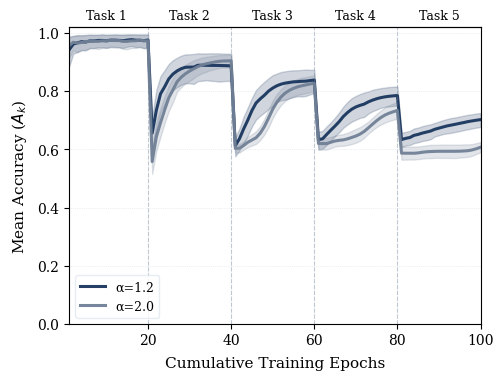


Condition       | Final Acc (95% CI)      | BWT (95% CI)           
-----------------------------------------------------------------
α=1.2           | 0.7019 [0.6735, 0.7230] | -0.1101 [-0.1417, -0.0881]
α=2.0           | 0.6069 [0.5897, 0.6251] | -0.0495 [-0.0576, -0.0421]


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import bootstrap
import re  # To safely extract seed integers from folder names

# --- Configuration ---
results_path = Path("./fashion_gpm0.97_fc10")
acc_threshold = 0.0
num_tasks = 5

def plot_multiple_accuracies_bootstrapped(param_pairs, n_boot=1000):
    """
    Plots the Mean Average Accuracy (Ak) with bootstrapped 95% Confidence Intervals.
    Handles randomized sequence folders formatted as folder_name_s{seed}
    """
    master_plot_data = []
    task_transition_epochs = None
    stats_summary = {} # Structure: {condition: {'acc': [], 'bwt': []}}

    for alpha, g, lr in param_pairs:
        condition_label = f"α={alpha}"
        stats_summary[condition_label] = {'acc': [], 'bwt': []}

        # Base folder naming pattern without seed suffix
        base_folder_pattern = f"decay_alpha_{alpha}_g_{g}_lr_{lr}"

        # Find all seed folders matching this base condition name (e.g., base_name_s0, base_name_s1...)
        matching_seed_folders = list(results_path.glob(f"{base_folder_pattern}_s*"))

        if not matching_seed_folders:
            print(f"Skipping parameter set: {base_folder_pattern} (No matching seed folders found).")
            continue

        seed_count = 0

        # Iterate through every seed folder found
        for folder_path in matching_seed_folders:
            # Extract seed integer using regex to preserve the "Seed ID" for the bootstrap unit
            seed_match = re.search(r'_s(\d+)$', folder_path.name)
            if seed_match:
                seed_id = int(seed_match.group(1))
            else:
                seed_id = seed_count  # Fallback just in case

            # Since each folder corresponds to exactly one seed run, look for the internal CSV
            csv_files = list(folder_path.glob("results_log_seed_*.csv"))
            if not csv_files:
                continue

            csv_file = csv_files[0] # Grab the singular log inside this folder
            df = pd.read_csv(csv_file)

            if df["task_1_acc"].iloc[-1] < acc_threshold:
                continue

            # --- CALCULATING AGGREGATES ---
            final_row = df.iloc[-1]
            task_cols = [f"task_{i}_acc" for i in range(1, num_tasks + 1)]
            stats_summary[condition_label]['acc'].append(final_row[task_cols].mean())

            bwt_elements = []
            for t in range(1, num_tasks):
                r_ii = df[df['task_id'] == t].iloc[-1][f"task_{t}_acc"]
                r_ni = final_row[f"task_{t}_acc"]
                bwt_elements.append(r_ni - r_ii)

            stats_summary[condition_label]['bwt'].append(sum(bwt_elements) / len(bwt_elements))
            # ------------------------------

            seed_count += 1

            # Process Epochs for Ak calculation
            for idx, row in df.iterrows():
                current_task_id = int(row['task_id'])
                task_cols = [f"task_{i}_acc" for i in range(1, current_task_id + 1)]
                mean_acc = row[task_cols].mean()

                master_plot_data.append({
                    "Total Epoch": idx + 1,
                    "Average Accuracy": mean_acc,
                    "Condition": condition_label,
                    "Seed": seed_id  # Stabilizes bootstrap resamples across matching seed trajectories
                })

            if task_transition_epochs is None:
                task_transition_epochs = df.groupby('task_id').size().cumsum().tolist()

        print(f"Processed {seed_count} seed folders for {condition_label}")

    if not master_plot_data:
        print("No data found to plot.")
        return

    plot_df = pd.DataFrame(master_plot_data)

    # 1. 1.5x scaling logic from your setup (Width ~4.92in, Height ~3.69in)
    width, height = 3.281 * 1.5, 2.461 * 1.5

    # 2. GLOBAL STYLING OVERRIDES (Times New Roman & Spine adjustments)
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
        "font.size": 11,          # Matches 10-11pt text layout size nicely
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,       # Vectorized font safety for IEEE/Xplore systems
        "ps.fonttype": 42
    })

    fig, ax = plt.subplots(figsize=(width, height), constrained_layout=True)

    # 3. HIGH-CONTRAST ACADEMIC PALETTE
    # Maps specific color signatures directly to your Condition strings
    custom_palette = {
        "α=1.2": "#1A365D",  # Deep Indigo/Navy (Ours - Signal Tunneling)
        "α=2.0": "#718096"   # Muted Slate Grey (Baseline - Plasticity Collapse)
    }

    # 4. PLOT EXECUTION
    sns.lineplot(
        data=plot_df,
        x="Total Epoch",
        y="Average Accuracy",
        hue="Condition",
        palette=custom_palette,   # Uses the professional contrast palette
        errorbar=("ci", 95),
        n_boot=n_boot,
        linewidth=2.2,            # Clean vector line weight
        alpha=0.95,
        ax=ax
    )

    # 5. TRANSITION AND MARGIN HYGIENE
    if task_transition_epochs:
        for t_idx, epoch_mark in enumerate(task_transition_epochs[:-1]):
            ax.axvline(x=epoch_mark, color='#718096', linestyle='--', linewidth=0.8, alpha=0.4)

    # Secondary X-Axis setup for Task Midpoints
    task_midpoints = [(task_transition_epochs[i] + task_transition_epochs[i+1])/2
                      for i in range(len(task_transition_epochs)-1)]
    first_midpoint = task_transition_epochs[0] / 2
    task_midpoints.insert(0, first_midpoint)

    secax = ax.secondary_xaxis('top')
    secax.set_xticks(task_midpoints)
    secax.set_xticklabels([f"Task {i+1}" for i in range(len(task_midpoints))], fontsize=9)
    secax.tick_params(axis='x', which='both', length=0)

    # 6. BOUNDS & LABEL POLISHING
    ax.set_ylim(0, 1.02)
    ax.set_xlim(1, plot_df["Total Epoch"].max())
    ax.set_ylabel("Mean Accuracy ($A_k$)", labelpad=6)
    ax.set_xlabel("Cumulative Training Epochs", labelpad=6)

    # Grid styling
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, color='#CBD5E0', alpha=0.7)

    # Legend anchoring (placing it cleanly out of the way of the ascending plot data)
    ax.legend(loc="lower left", frameon=True, facecolor="white", edgecolor="#E2E8F0")

    # Remove top and right border lines for a cleaner modern aesthetic
    sns.despine(ax=ax, top=False, right=False) # top=False preserves the secondary axis line cleanly

    plt.savefig("fashion_acc.pdf", bbox_inches="tight", dpi=300)
    plt.show()

    print("\n" + "="*65)
    print(f"{'Condition':<15} | {'Final Acc (95% CI)':<23} | {'BWT (95% CI)':<23}")
    print("-" * 65)
    for condition, data in stats_summary.items():
        # Convert list data to numpy arrays for scipy processing
        acc_array = np.array(data['acc'])
        bwt_array = np.array(data['bwt'])

        # Check if we have enough seed samples to bootstrap safely
        if len(acc_array) > 1:
            try:
                # 1. Bootstrap Final Average Accuracy
                res_acc = bootstrap((acc_array,), np.mean, confidence_level=0.95,
                                    method='BCa', n_resamples=n_boot)
                acc_str = f"{acc_array.mean():.4f} [{res_acc.confidence_interval.low:.4f}, {res_acc.confidence_interval.high:.4f}]"
            except Exception:
                # Fallback to percentile bootstrap if BCa encounters extreme sample variance limits
                res_acc = bootstrap((acc_array,), np.mean, confidence_level=0.95,
                                    method='percentile', n_resamples=n_boot)
                acc_str = f"{acc_array.mean():.4f} [{res_acc.confidence_interval.low:.4f}, {res_acc.confidence_interval.high:.4f}]"

            try:
                # 2. Bootstrap Backward Transfer (BWT)
                res_bwt = bootstrap((bwt_array,), np.mean, confidence_level=0.95,
                                    method='BCa', n_resamples=n_boot)
                bwt_str = f"{bwt_array.mean():.4f} [{res_bwt.confidence_interval.low:.4f}, {res_bwt.confidence_interval.high:.4f}]"
            except Exception:
                res_bwt = bootstrap((bwt_array,), np.mean, confidence_level=0.95,
                                    method='percentile', n_resamples=n_boot)
                bwt_str = f"{bwt_array.mean():.4f} [{res_bwt.confidence_interval.low:.4f}, {res_bwt.confidence_interval.high:.4f}]"
        else:
            # Fallback format if only 1 seed is found or processed
            acc_str = f"{acc_array.mean():.4f} [N/A]"
            bwt_str = f"{bwt_array.mean():.4f} [N/A]"

        print(f"{condition:<15} | {acc_str:<23} | {bwt_str:<23}")
    print("="*65)

# --- Execution ---
comparison_list = [
    (1.2, 1.0, 0.01),
    (2.0, 1.0, 0.01)
]

# Set n_boot to 10000 for your final publication plot!
plot_multiple_accuracies_bootstrapped(comparison_list, n_boot=10000)

Processed 20 seed folders for α=1.2, g=1.0
Processed 20 seed folders for α=2.0, g=1.0


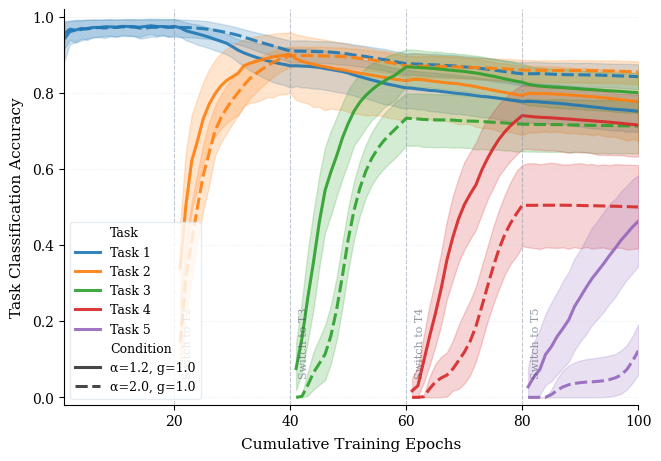


Condition       | Task     | Final Accuracy (95% CI Range) 
----------------------------------------------------------------------
α=1.2, g=1.0    | Task 1   | 0.7521 [0.6930, 0.8010]       
α=1.2, g=1.0    | Task 2   | 0.7773 [0.6354, 0.8402]       
α=1.2, g=1.0    | Task 3   | 0.8011 [0.7431, 0.8475]       
α=1.2, g=1.0    | Task 4   | 0.7157 [0.6290, 0.7898]       
α=1.2, g=1.0    | Task 5   | 0.4634 [0.3470, 0.5868]       
----------------------------------------------------------------------
α=2.0, g=1.0    | Task 1   | 0.8430 [0.8101, 0.8755]       
α=2.0, g=1.0    | Task 2   | 0.8554 [0.8195, 0.8805]       
α=2.0, g=1.0    | Task 3   | 0.7132 [0.6360, 0.7757]       
α=2.0, g=1.0    | Task 4   | 0.5003 [0.3856, 0.6064]       
α=2.0, g=1.0    | Task 5   | 0.1227 [0.0674, 0.2013]       
----------------------------------------------------------------------


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
from scipy.stats import bootstrap

# --- Configuration ---
# Updated to match your final run storage directory
results_path = Path("./fashion_gpm0.97_fc10")
task_success_threshold = 0.00  # Ensure the model actually learned Task 1
num_tasks = 5

def plot_individual_tasks_with_seeds(param_pairs, n_boot=1000):
    """
    Plots individual task accuracy lines aggregated over multiple seeds.
    Handles randomized sequence folders formatted as folder_name_s{seed}
    and computes true 95% BCa bootstrapped intervals for task outputs.
    """
    master_plot_data = []
    task_transition_epochs = None

    # Container for final task accuracies over seeds
    final_task_stats = {}

    for alpha, g, lr in param_pairs:
        condition_label = f"α={alpha}, g={g}"
        final_task_stats[condition_label] = {f"Task {t}": [] for t in range(1, num_tasks + 1)}

        # Base folder naming pattern without seed suffix
        base_folder_pattern = f"decay_alpha_{alpha}_g_{g}_lr_{lr}"

        # Find all seed folders matching this base condition name
        matching_seed_folders = list(results_path.glob(f"{base_folder_pattern}_s*"))

        if not matching_seed_folders:
            print(f"Skipping parameter set: {base_folder_pattern} (No matching seed folders found).")
            continue

        seed_count = 0

        # Iterate through every matching seed folder found
        for folder_path in matching_seed_folders:
            # Safely extract seed integer using corrected digit matching regex
            seed_match = re.search(r'_s(\d+)$', folder_path.name)
            seed_id = int(seed_match.group(1)) if seed_match else seed_count

            # Identify the singular log CSV file inside this seed's directory
            csv_files = list(folder_path.glob("results_log_seed_*.csv"))
            if not csv_files:
                continue

            csv_file = csv_files[0]
            df = pd.read_csv(csv_file)

            # Trainability Filter: Skip seeds where Task 1 didn't converge
            if df[df['task_id'] == 1]['task_1_acc'].max() < task_success_threshold:
                continue

            # --- Capture Final Accuracies per Task ---
            final_row = df.iloc[-1]
            for t in range(1, num_tasks + 1):
                col_name = f"task_{t}_acc"
                if col_name in final_row and not pd.isna(final_row[col_name]):
                    final_task_stats[condition_label][f"Task {t}"].append(final_row[col_name])

            seed_count += 1

            # Individual Curve Extraction via manual unpivoting (melting)
            for idx, row in df.iterrows():
                for t in range(1, num_tasks + 1):
                    col = f"task_{t}_acc"
                    if col in row and not pd.isna(row[col]):
                        master_plot_data.append({
                            "Total Epoch": idx + 1,
                            "Accuracy": row[col],
                            "Task": f"Task {t}",
                            "Condition": condition_label,
                            "Seed": seed_id  # Matches entire tracking trajectories together
                        })

            # Capture transition points from the first valid seed
            if task_transition_epochs is None:
                task_transition_epochs = df.groupby('task_id').size().cumsum().tolist()

        print(f"Processed {seed_count} seed folders for {condition_label}")

    if not master_plot_data:
        print("No data found.")
        return

    plot_df = pd.DataFrame(master_plot_data)

    # --- Unified Global Font Updates for Publication Look ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
        "font.size": 11,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })

    # Subplot size targeting standard column limits
    fig, ax = plt.subplots(figsize=(6.5, 4.5), constrained_layout=True)

    # Clean, distinguishable task color mapping
    sns.lineplot(
        data=plot_df,
        x="Total Epoch",
        y="Accuracy",
        hue="Task",
        style="Condition" if len(param_pairs) > 1 else None,
        errorbar=("ci", 95),
        n_boot=n_boot,
        palette="tab10",
        linewidth=2.2,
        alpha=0.9,
        ax=ax
    )

    # Task transition vertical lines
    if task_transition_epochs:
        for t_idx, epoch_mark in enumerate(task_transition_epochs[:-1]):
            ax.axvline(x=epoch_mark, color='#718096', linestyle='--', linewidth=0.8, alpha=0.4)
            ax.text(epoch_mark + 1.5, 0.05, f"Switch to T{t_idx+2}",
                    fontsize=8, rotation=90, color='#4A5568', alpha=0.6, verticalalignment='bottom')

    ax.set_ylabel("Task Classification Accuracy", labelpad=6)
    ax.set_xlabel("Cumulative Training Epochs", labelpad=6)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlim(1, plot_df["Total Epoch"].max())
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, color='#CBD5E0', alpha=0.6)

    # Float the legend box neatly inside the grid spacing
    ax.legend(loc='lower left', frameon=True, facecolor="white", edgecolor="#E2E8F0")
    sns.despine(ax=ax, top=True, right=True)

    #plt.savefig("individual_task_decay.pdf", bbox_inches="tight", dpi=300)
    plt.show()

    # --- Bootstrapped Task Summary Output ---
    print("\n" + "="*70)
    print(f"{'Condition':<15} | {'Task':<8} | {'Final Accuracy (95% CI Range)':<30}")
    print("-" * 70)
    for condition, tasks in final_task_stats.items():
        for task_name, acc_list in tasks.items():
            acc_array = np.array(acc_list)

            if len(acc_array) > 1:
                try:
                    # Execute asymmetric Bias-Corrected bootstrap
                    res = bootstrap((acc_array,), np.mean, confidence_level=0.95,
                                    method='BCa', n_resamples=n_boot)
                    ci_str = f"{acc_array.mean():.4f} [{res.confidence_interval.low:.4f}, {res.confidence_interval.high:.4f}]"
                except Exception:
                    # Percentile fallback protection for task configurations with near-zero variance slices
                    res = bootstrap((acc_array,), np.mean, confidence_level=0.95,
                                    method='percentile', n_resamples=n_boot)
                    ci_str = f"{acc_array.mean():.4f} [{res.confidence_interval.low:.4f}, {res.confidence_interval.high:.4f}]"
            else:
                ci_str = f"{acc_array.mean():.4f} [N/A]" if len(acc_array) == 1 else "N/A"

            print(f"{condition:<15} | {task_name:<8} | {ci_str:<30}")
        print("-" * 70)
    print("="*70)

# --- Execution ---
comparison_list = [
    (1.2, 1.0, 0.01),
    (2.0, 1.0, 0.01)
]

# Set n_boot to 10000 for your final publication formatting runs!
plot_individual_tasks_with_seeds(comparison_list, n_boot=10000)

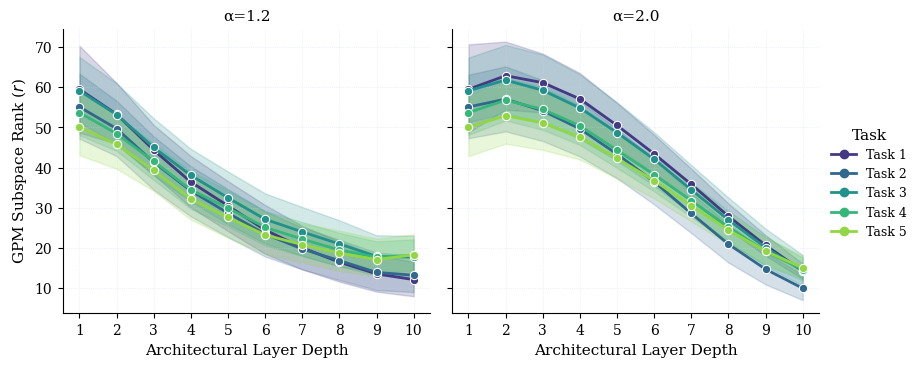


Condition       | Task     | Total Rank (95% CI)     | Peak Rank (95% CI)      | Rank Delta     
-----------------------------------------------------------------------------------------------
α=1.2           | Task 1   | 310.4 [259.5, 362.8]    | 61.8 [51.7, 71.8]       | 47.5 [35.1, 58.7]
α=1.2           | Task 2   | 295.9 [239.8, 352.8]    | 55.6 [47.9, 63.8]       | 42.0 [36.3, 48.2]
α=1.2           | Task 3   | 335.4 [279.2, 401.6]    | 59.6 [51.9, 68.7]       | 41.5 [35.0, 47.4]
α=1.2           | Task 4   | 310.5 [271.7, 351.1]    | 54.3 [49.4, 61.0]       | 35.6 [30.4, 41.5]
α=1.2           | Task 5   | 292.8 [252.9, 356.2]    | 50.5 [44.2, 58.9]       | 31.8 [25.9, 38.8]
-----------------------------------------------------------------------------------------------
α=2.0           | Task 1   | 433.0 [381.5, 485.1]    | 66.3 [57.5, 75.2]       | 45.3 [35.6, 55.1]
α=2.0           | Task 2   | 369.8 [314.1, 428.7]    | 57.9 [49.6, 66.2]       | 45.2 [39.6, 51.5]
α=2.0           |

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
from pathlib import Path
from scipy.stats import bootstrap

# --- Configuration ---
# Updated path to match your final data output root
results_path = Path("./fashion_gpm0.97_fc10")
num_tasks = 5

def plot_layer_rank_profiles(param_pairs, n_boot=1000):
    """
    Plots the rank of each layer (y-axis) against layer depth (x-axis).
    Tracks how representation memory partitions across the deep manifold architecture.
    """
    profile_data = []
    # Dictionary to store metrics per seed condition:
    # {condition: {task: {'total': [], 'peak': [], 'delta': []}}}
    rank_metrics = {}

    for alpha, g, lr in param_pairs:
        condition_label = f"α={alpha}"
        rank_metrics[condition_label] = {}

        # Base folder naming pattern without seed suffix
        base_folder_pattern = f"decay_alpha_{alpha}_g_{g}_lr_{lr}"

        # Pull matching folders for all 20 macro seeds dynamically
        matching_seed_folders = list(results_path.glob(f"{base_folder_pattern}_s*"))

        if not matching_seed_folders:
            print(f"Skipping parameter set: {base_folder_pattern} (No matching seed folders found).")
            continue

        for folder_path in matching_seed_folders:
            # Safely extract seed integer using corrected digit matching regex
            seed_match = re.search(r'_s(\d+)$', folder_path.name)
            seed_id = int(seed_match.group(1)) if seed_match else 0

            # Find the local log CSV tracking this seed run
            csv_files = list(folder_path.glob("results_log_seed_*.csv"))
            if not csv_files:
                continue

            csv_file = csv_files[0]
            df = pd.read_csv(csv_file)

            # 1. Identify Snapshot Rows
            # Ranks are updated and logged precisely at the final epoch of each task profile.
            snapshots = df.groupby('task_id').tail(1)

            for _, row in snapshots.iterrows():
                task_id = int(row['task_id'])
                task_label = f"Task {task_id}"

                # 2. Extract Layer Ranks
                rank_cols = [c for c in df.columns if c.startswith('layer_') and c.endswith('_rank')]

                if task_label not in rank_metrics[condition_label]:
                    rank_metrics[condition_label][task_label] = {'total': [], 'peak': [], 'delta': []}

                # Compile ordered layer ranks to assess geometric shape profiles
                ordered_ranks = [row[f'layer_{i}_rank'] for i in range(len(rank_cols))]

                # Metric A: Total Capacity footprint (Structural Trace)
                total_r = sum(ordered_ranks)

                # Metric B: Peak Compression stress (Bottleneck locator)
                peak_r = max(ordered_ranks)

                # Metric C: Tapering Delta (Measures signal attenuation across the depth skeleton)
                delta_r = ordered_ranks[0] - ordered_ranks[-1]

                rank_metrics[condition_label][task_label]['total'].append(total_r)
                rank_metrics[condition_label][task_label]['peak'].append(peak_r)
                rank_metrics[condition_label][task_label]['delta'].append(delta_r)

                for col in rank_cols:
                    layer_idx = int(re.search(r"layer_(\d+)_rank", col).group(1)) + 1

                    profile_data.append({
                        "Layer Depth": layer_idx,
                        "Rank": row[col],
                        "Task": task_label,
                        "Condition": condition_label,
                        "Seed": seed_id  # Critical token matching variable for Seaborn bootstrap units
                    })

    if not profile_data:
        print("No rank data found in CSVs.")
        return

    plot_df = pd.DataFrame(profile_data)

    # --- Unified Font Config for Academic Publication Look ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
        "font.size": 11,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42
    })

    # Faceted plot grid config using relplot to isolate alpha styles cleanly side-by-side
    g = sns.relplot(
        data=plot_df,
        x="Layer Depth",
        y="Rank",
        hue="Task",
        col="Condition",
        kind="line",
        marker="o",
        errorbar=("ci", 95),
        n_boot=n_boot,
        linewidth=2.0,
        palette="viridis",
        height=3.8,           # Matches your two-column manuscript layout height limitations
        aspect=1.1,
        facet_kws={'sharey': True}
    )

    # Clean axes & metadata tags matching the visual tone of your earlier accuracy figures
    g.set_axis_labels("Architectural Layer Depth", "GPM Subspace Rank ($r$)")
    g.set_titles(template="{col_name}")

    for ax in g.axes.flat:
        ax.grid(True, which='both', linestyle=':', linewidth=0.5, color='#CBD5E0', alpha=0.6)
        ax.set_xticks(range(1, int(plot_df["Layer Depth"].max()) + 1))
        # Ensure label tags don't overlap boundaries
        ax.tick_params(axis='both', which='major', pad=4)

    # Clean up outer spines
    sns.despine(top=True, right=True)

    g.savefig("layer_rank_profiles.pdf", bbox_inches="tight", dpi=300)
    plt.show()

    # --- Bootstrapped Asymmetric Macro Summary Output ---
    print("\n" + "="*95)
    print(f"{'Condition':<15} | {'Task':<8} | {'Total Rank (95% CI)':<23} | {'Peak Rank (95% CI)':<23} | {'Rank Delta':<15}")
    print("-" * 95)

    for condition in sorted(rank_metrics.keys()):
        for task in sorted(rank_metrics[condition].keys()):
            m = rank_metrics[condition][task]

            # Reusable asymmetric bootstrap processor mapping
            def get_ci_string(data_list):
                arr = np.array(data_list)
                if len(arr) > 1:
                    try:
                        res = bootstrap((arr,), np.mean, confidence_level=0.95, method='BCa', n_resamples=n_boot)
                        return f"{arr.mean():.1f} [{res.confidence_interval.low:.1f}, {res.confidence_interval.high:.1f}]"
                    except Exception:
                        res = bootstrap((arr,), np.mean, confidence_level=0.95, method='percentile', n_resamples=n_boot)
                        return f"{arr.mean():.1f} [{res.confidence_interval.low:.1f}, {res.confidence_interval.high:.1f}]"
                return f"{arr.mean():.1f} [N/A]" if len(arr) == 1 else "N/A"

            total_str = get_ci_string(m['total'])
            peak_str = get_ci_string(m['peak'])
            delta_str = get_ci_string(m['delta'])

            print(f"{condition:<15} | {task:<8} | {total_str:<23} | {peak_str:<23} | {delta_str:<15}")
        print("-" * 95)
    print("="*95)

# --- Execution ---
comparison_list = [
    (1.2, 1.0, 0.01),
    (2.0, 1.0, 0.01)
]

# Push n_boot to 10000 when generating your absolute final document charts!
plot_layer_rank_profiles(comparison_list, n_boot=10000)

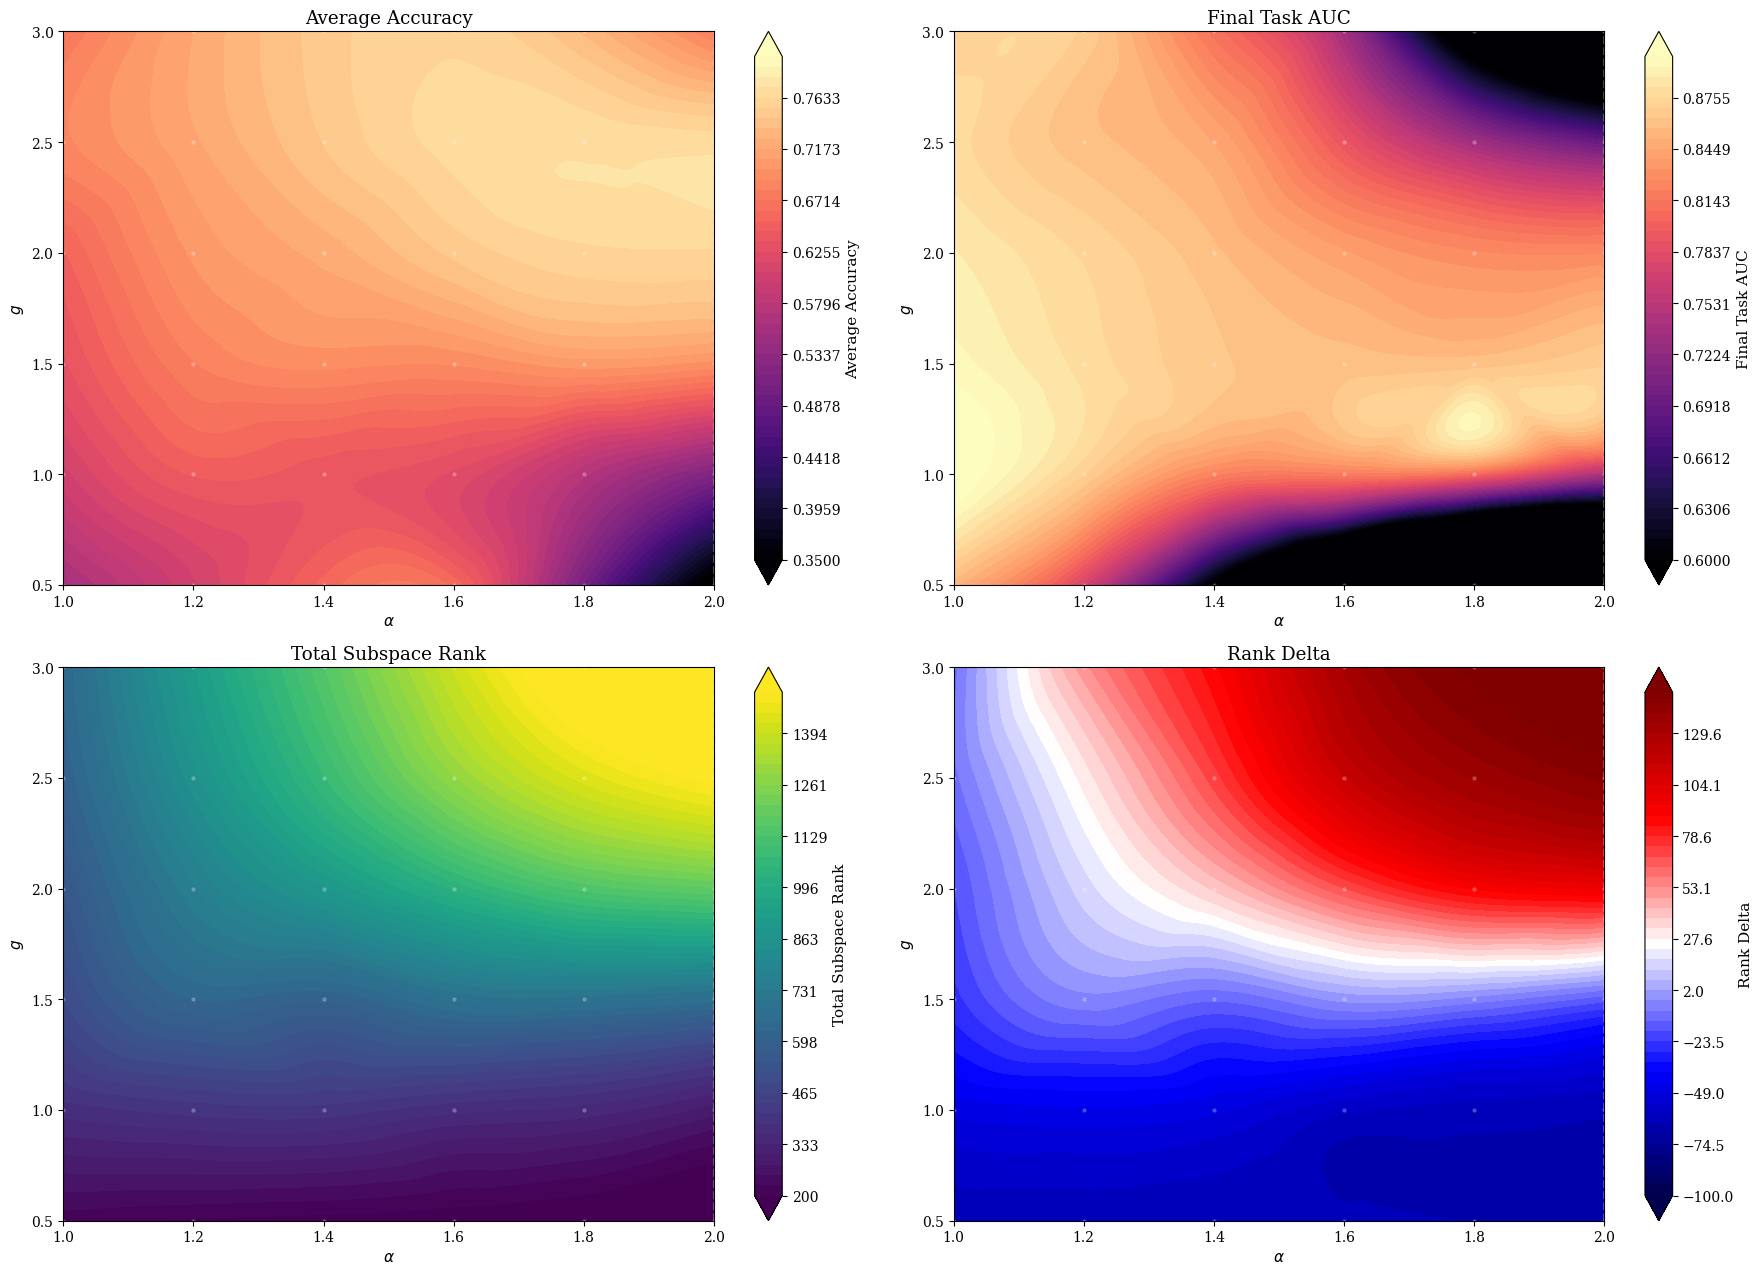

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from pathlib import Path
from scipy.interpolate import griddata

# --- Configuration ---
results_path = Path("./sweep_fashion_gpm0.97_fc10")
num_tasks = 5

def get_metrics_from_csv(csv_file):
    df = pd.read_csv(csv_file)

    # --- 1. Average Accuracy (Ak) ---
    final_row = df.iloc[-1]
    task_cols = [f"task_{i}_acc" for i in range(1, num_tasks + 1)]
    ak = final_row[task_cols].mean()

    # --- 2. Plasticity AUC (Task 5 "Snap") ---
    # We isolate only the epochs where Task 5 was the active training task
    t5_df = df[df['task_id'] == num_tasks]

    if not t5_df.empty:
        t5_acc_series = t5_df[f"task_{num_tasks}_acc"].values
        # Normalize AUC by the number of epochs to keep the score between 0 and 1
        # A 'perfect' learner who hits 1.0 at epoch 1 and stays there would have score ~1.0
        plasticity_auc = np.trapezoid(t5_acc_series) / len(t5_acc_series)
    else:
        plasticity_auc = 0

    # --- 3. Capacity Tax (Total Rank) ---
    total_rank = final_row["total_rank_sum"]

    # Identify layer columns (assuming they are named layer_0_rank, layer_1_rank, etc.)
    rank_cols = sorted([c for c in df.columns if c.startswith('layer_') and c.endswith('_rank')],
                       key=lambda x: int(re.search(r'\d+', x).group()))

    # Calculate the Delta (Last Layer Rank minus First Layer Rank)
    first_layer_rank = final_row[rank_cols[0]]
    last_layer_rank = final_row[rank_cols[-1]]
    rank_delta = last_layer_rank - first_layer_rank

    return ak, plasticity_auc, total_rank, rank_delta

def plot_multi_metric_sweep(use_median=False, vrange_dict=None):
    """
    vrange_dict: dict of {metric_name: (vmin, vmax)}
    Example: {"Average Accuracy": (0.3, 0.8)}
    """
    if vrange_dict is None:
        vrange_dict = {}

    sweep_results = []
    folder_pattern = re.compile(r"alpha_([\d\.]+)_g_([\d\.]+)")

    for folder in results_path.iterdir():
        if not folder.is_dir(): continue
        match = folder_pattern.search(folder.name)
        if not match: continue

        alpha, g = float(match.group(1)), float(match.group(2))

        seed_metrics = []
        for csv_file in folder.glob("results_log_seed_*.csv"):
            try:
                seed_metrics.append(get_metrics_from_csv(csv_file))
            except Exception:
                continue

        if seed_metrics:
            metrics_array = np.array(seed_metrics)
            agg_vals = np.median(metrics_array, axis=0) if use_median else np.mean(metrics_array, axis=0)

            sweep_results.append({
                "alpha": alpha, "g": g,
                "Average Accuracy": agg_vals[0],
                "Final Task AUC": agg_vals[1],
                "Total Subspace Rank": agg_vals[2],
                "Rank Delta": agg_vals[3]
            })

    df_sweep = pd.DataFrame(sweep_results)
    metrics_to_plot = ["Average Accuracy", "Final Task AUC", "Total Subspace Rank", "Rank Delta"]
    cmaps = ["magma", "magma", "viridis", "seismic"]

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    axes = axes.flatten()

    for i, metric in enumerate(metrics_to_plot):
        xi = np.linspace(df_sweep['alpha'].min(), df_sweep['alpha'].max(), 100)
        yi = np.linspace(df_sweep['g'].min(), df_sweep['g'].max(), 100)
        xi, yi = np.meshgrid(xi, yi)

        zi = griddata((df_sweep['alpha'], df_sweep['g']), df_sweep[metric], (xi, yi), method='cubic')

        # Get custom vmin/vmax or use data defaults
        vmin, vmax = vrange_dict.get(metric, (None, None))

        ax = axes[i]
        # Use contourf with manual levels if vmin/vmax are provided
        if vmin is not None and vmax is not None:
            levels = np.linspace(vmin, vmax, 50)
            contour = ax.contourf(xi, yi, zi, levels=levels, cmap=cmaps[i], extend='both')
        else:
            contour = ax.contourf(xi, yi, zi, levels=50, cmap=cmaps[i])

        fig.colorbar(contour, ax=ax, label=metric)

        ax.scatter(df_sweep['alpha'], df_sweep['g'], c='white', s=5, alpha=0.2)
        ax.set_xlabel(r"$\alpha$")
        ax.set_ylabel(r"$g$")
        ax.set_title(f"{metric}")
        ax.axvline(x=2.0, color='white', linestyle='--', alpha=0.3)

    #plt.suptitle(f"Phase Analysis ({'Median' if use_median else 'Mean'} Aggregate)", fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("phase_diagram.pdf", bbox_inches="tight")
    plt.show()

# --- Execution ---
# Adjust these values to zoom in on the " Ruggedness" transitions
custom_ranges = {
    "Average Accuracy": (0.35, 0.80),    # Highlight the drop-off zones
    "Final Task AUC": (0.6, 0.9), # Contrast the high-plasticity HT zones
    "Total Subspace Rank": (200, 1500),    # Zoom into the capacity differences
    "Rank Delta": (-100, 150) # Capture the efficiency peak
}

plot_multi_metric_sweep(use_median=False, vrange_dict=custom_ranges)

Processing CKA matrices across 20 seed runs...
 ➔ Finished computing matrix for Seed 10
 ➔ Finished computing matrix for Seed 4
 ➔ Finished computing matrix for Seed 11
 ➔ Finished computing matrix for Seed 8
 ➔ Finished computing matrix for Seed 5
 ➔ Finished computing matrix for Seed 14
 ➔ Finished computing matrix for Seed 69
 ➔ Finished computing matrix for Seed 67
 ➔ Finished computing matrix for Seed 42
 ➔ Finished computing matrix for Seed 7
 ➔ Finished computing matrix for Seed 13
 ➔ Finished computing matrix for Seed 12
 ➔ Finished computing matrix for Seed 3
 ➔ Finished computing matrix for Seed 1
 ➔ Finished computing matrix for Seed 9
 ➔ Finished computing matrix for Seed 0
 ➔ Finished computing matrix for Seed 16
 ➔ Finished computing matrix for Seed 15
 ➔ Finished computing matrix for Seed 6
 ➔ Finished computing matrix for Seed 2

Running 10000 BCa bootstrap resamples per matrix cell...


/home/yihao/miniconda3/envs/honours/lib/python3.12/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in scalar divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/home/yihao/miniconda3/envs/honours/lib/python3.12/site-packages/scipy/_lib/_util.py:352: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


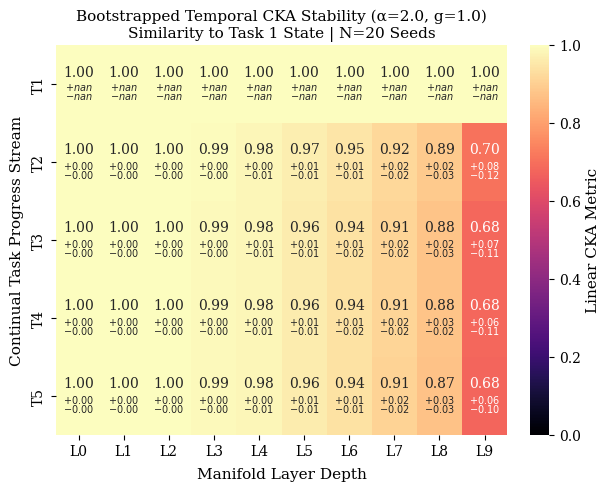

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import re
from pathlib import Path
from scipy.stats import bootstrap

# --- Configuration ---
results_root = Path("./fashion_gpm0.97_fc10")
num_tasks = 5
num_layers = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. CORE CKA MATHEMATICS (UNCHANGED) ---
def linear_HSIC(K, L):
    n = K.shape[0]
    H = torch.eye(n, device=K.device) - (1.0 / n)
    K_centered = H @ K @ H
    L_centered = H @ L @ H
    return torch.trace(K_centered @ L_centered) / ((n - 1) ** 2)

def compute_cka(h1, h2):
    h1, h2 = h1.float(), h2.float()
    K = h1 @ h1.T
    L = h2 @ h2.T
    hsic_kl = linear_HSIC(K, L)
    hsic_kk = linear_HSIC(K, K)
    hsic_ll = linear_HSIC(L, L)
    return (hsic_kl / torch.sqrt(hsic_kk * hsic_ll)).item()

def get_temporal_cka(model, path_t1, path_t2, probe_batch, layer_idx):
    """Computes CKA for a layer between two snapshots."""
    model.eval()

    # Snapshot 1
    snap1 = torch.load(path_t1, map_location=device)
    model.load_state_dict(snap1["state_dict"])
    with torch.no_grad():
        h1_dict = model.get_pre_activations(probe_batch)
        h1 = h1_dict["classifier"] if layer_idx == 9 else h1_dict[layer_idx]

    # Snapshot 2
    snap2 = torch.load(path_t2, map_location=device)
    model.load_state_dict(snap2["state_dict"])
    with torch.no_grad():
        h2_dict = model.get_pre_activations(probe_batch)
        h2 = h2_dict["classifier"] if layer_idx == 9 else h2_dict[layer_idx]

    return compute_cka(h1, h2)

# --- 2. MACRO-ENSEMBLE BOOTSTRAP EXECUTOR ---
def compile_bootstrapped_cka(alpha, g, lr, test_tasks, model_shell, n_boot=1000, ref_task_idx=1):
    """
    Crawls your randomized folder layout, computes a 10x10 matrix per seed,
    and returns the 95% BCa confidence interval limits for every single coordinate cell.
    """
    base_folder_pattern = f"decay_alpha_{alpha}_g_{g}_lr_{lr}"
    matching_seed_folders = list(results_root.glob(f"{base_folder_pattern}_s*"))

    if not matching_seed_folders:
        print(f"No folders found for {base_folder_pattern}")
        return

    # Use a fixed, stable evaluation probe batch from Task 1 (e.g., first 256 images)
    # Keeping this static isolates the structural randomness entirely to weight trajectories
    fixed_probe = test_tasks[0][0][:512].to(device)

    # Tensor to store raw 2D CKA matrices: [num_seeds, num_tasks, num_layers]
    all_seed_matrices = []

    print(f"Processing CKA matrices across {len(matching_seed_folders)} seed runs...")

    for folder_path in matching_seed_folders:
        seed_match = re.search(r'_s(\d+)$', folder_path.name)
        seed_id = int(seed_match.group(1)) if seed_match else 0

        checkpoints_path = folder_path / "checkpoints"
        snap_ref_path = checkpoints_path / f"snapshot_T{ref_task_idx}_E19.pt"

        if not snap_ref_path.exists():
            continue

        seed_matrix = np.zeros((num_tasks, num_layers))

        for t_idx in range(num_tasks):
            curr_task = t_idx + 1
            snap_curr_path = checkpoints_path / f"snapshot_T{curr_task}_E19.pt"

            if not snap_curr_path.exists():
                continue

            for l_idx in range(num_layers):
                score = get_temporal_cka(model_shell, snap_ref_path, snap_curr_path, fixed_probe, l_idx)
                seed_matrix[t_idx, l_idx] = score

        all_seed_matrices.append(seed_matrix)
        print(f" ➔ Finished computing matrix for Seed {seed_id}")

    all_seed_matrices = np.array(all_seed_matrices)  # Shape: [N_seeds, 5, 10]
    num_valid_seeds = all_seed_matrices.shape[0]

    # Containers for the final aggregated bootstrap estimates
    mean_matrix = np.zeros((num_tasks, num_layers))
    ci_lower_matrix = np.zeros((num_tasks, num_layers))
    ci_upper_matrix = np.zeros((num_tasks, num_layers))

    print(f"\nRunning {n_boot} BCa bootstrap resamples per matrix cell...")
    # Bootstrap every coordinate cell independently across the seed axis
    for t in range(num_tasks):
        for l in range(num_layers):
            cell_samples = all_seed_matrices[:, t, l]
            mean_matrix[t, l] = cell_samples.mean()

            if num_valid_seeds > 1:
                try:
                    res = bootstrap((cell_samples,), np.mean, confidence_level=0.95,
                                    method='BCa', n_resamples=n_boot)
                    ci_lower_matrix[t, l] = res.confidence_interval.low
                    ci_upper_matrix[t, l] = res.confidence_interval.high
                except Exception:
                    res = bootstrap((cell_samples,), np.mean, confidence_level=0.95,
                                    method='percentile', n_resamples=n_boot)
                    ci_lower_matrix[t, l] = res.confidence_interval.low
                    ci_upper_matrix[t, l] = res.confidence_interval.high
            else:
                ci_lower_matrix[t, l] = mean_matrix[t, l]
                ci_upper_matrix[t, l] = mean_matrix[t, l]

    # --- VISUALIZATION PHASE ---
    # Global Font Customization for Publication Layouts
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
        "font.size": 10,
        "pdf.fonttype": 42
    })

    fig, ax = plt.subplots(figsize=(6.0, 4.8), constrained_layout=True)

    # Create an annotation matrix that prints: Mean \n [-Lower, +Upper] deltas using Method 3 logic
    annot_labels = np.empty_like(mean_matrix, dtype=object)
    for t in range(num_tasks):
        for l in range(num_layers):
            m = mean_matrix[t, l]
            u_delta = ci_upper_matrix[t, l] - m
            l_delta = m - ci_lower_matrix[t, l]
            # Formats beautifully inside the heatmap cell grid
            annot_labels[t, l] = f"{m:.2f}\n$^{{+{u_delta:.2f}}}_{{-{l_delta:.2f}}}$"

    sns.heatmap(
        mean_matrix,
        annot=annot_labels,
        fmt="",
        cmap="magma",
        cbar_kws={'label': 'Linear CKA Metric'},
        xticklabels=[f"L{i}" for i in range(num_layers)],
        yticklabels=[f"T{i+1}" for i in range(num_tasks)],
        vmin=0.0,
        vmax=1.0,
        ax=ax
    )

    ax.set_title(f"Bootstrapped Temporal CKA Stability (α={alpha}, g={g})\nSimilarity to Task {ref_task_idx} State | N={num_valid_seeds} Seeds", fontsize=11)
    ax.set_xlabel("Manifold Layer Depth", labelpad=6)
    ax.set_ylabel("Continual Task Progress Stream", labelpad=6)

    plt.savefig(f"cka_heatmap_alpha_{alpha}.pdf", bbox_inches="tight", dpi=300)
    plt.show()

# --- 3. RUNTIME INVOCATION BLOCK ---
# Assuming test_tasks is already generated via your custom get_split_tasks code
test_model = GeneralMLP(784, 784, 10, 9, "tanh", bias=False).to(device)

# Generate your high-rigor publication plot
compile_bootstrapped_cka(alpha=2.0, g=1.0, lr=0.01, test_tasks=test_tasks, model_shell=test_model, n_boot=10000)

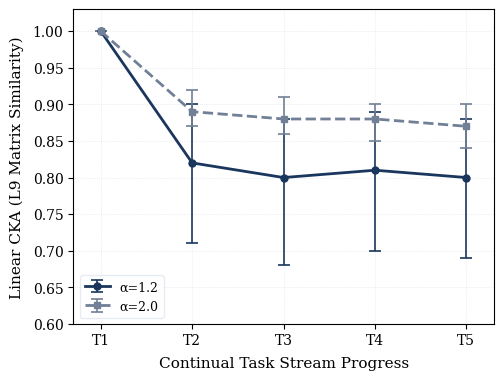

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. MANUAL DATA ENTRY ---
tasks = list(range(1, 6))

# 1. Means (Your existing display numbers)
cka_ht_mean = [1.0, 0.82, 0.80, 0.81, 0.80]
cka_gauss_mean = [1.0, 0.89, 0.88, 0.88, 0.87]

# 2. DELTAS: Format is [ [lower_deltas], [upper_deltas] ]
# Example values shown below. Replace with your actual calculated display deltas!
# (Note: Set Task 1 deltas to 0.0 since it is a locked reference)
ht_deltas = [
    [0.0, 0.11, 0.12, 0.11, 0.11],  # Lower deltas (Mean - Lower Bound)
    [0.0, 0.08, 0.08, 0.08, 0.08]   # Upper deltas (Upper Bound - Mean)
]

gauss_deltas = [
    [0.0, 0.02, 0.02, 0.03, 0.03],  # Lower deltas
    [0.0, 0.03, 0.03, 0.02, 0.03]   # Upper deltas
]

# --- 2. GLOBAL PUBLICATION TYPOGRAPHY ---
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# 3. Figure Dimension Limits (1.5x of your standard baseline column constraints)
width, height = 3.281 * 1.5, 2.461 * 1.5
fig, ax = plt.subplots(figsize=(width, height), constrained_layout=True)

# --- 3. EXECUTION WITH ASYMMETRIC ERROR BARS ---
# Heavy-Tailed Model (Ours: Deep Indigo/Navy)
ax.errorbar(
    x=tasks, y=cka_ht_mean, yerr=ht_deltas,
    marker='o', markersize=5, linewidth=2.0, color='#1A365D',
    capsize=4, capthick=1.2, elinewidth=1.2, # error bar cap customization
    label='α=1.2'
)

# Gaussian Model (Baseline: Muted Slate Grey)
ax.errorbar(
    x=tasks, y=cka_gauss_mean, yerr=gauss_deltas,
    marker='s', markersize=5, linewidth=2.0, color='#718096', linestyle='--',
    capsize=4, capthick=1.2, elinewidth=1.2,
    label='α=2.0'
)

# --- 4. GRAPH POLISHING & SPACING ---
ax.set_ylabel("Linear CKA (L9 Matrix Similarity)", labelpad=6)
ax.set_xlabel("Continual Task Stream Progress", labelpad=6)

# Force strict task boundaries and labeling
ax.set_xticks(tasks)
ax.set_xticklabels([f"T{i}" for i in tasks])
ax.set_xlim(0.7, 5.3)
ax.set_ylim(0.60, 1.03)

# Grid layout rules
ax.grid(True, which='both', linestyle=':', linewidth=0.5, color='#CBD5E0', alpha=0.7)

# Legend placement anchored inside the open bottom-left white space
ax.legend(loc="lower left", frameon=True, facecolor="white", edgecolor="#E2E8F0")

# Clear bounding box spines for a modern aesthetic
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(True)

# Save sharp vectorized vector asset directly into your paper assets directory
plt.savefig("fashion_cka.pdf", bbox_inches='tight', dpi=300)
# plt.show()

In [ ]:
import torch
import numpy as np
import pandas as pd
from pathlib import Path

# --- 1. CONFIGURATION ---
# Point this to the root of your alpha directory
BASE_PATH = Path("./results_fashion_fc10/split_fashion_alpha_2.0_g_3.0_lr_0.001/checkpoints")
OUTPUT_CSV = Path("../results/subspace_alignment_alpha_2.0.csv")
K_DIM = 10  # The rank of the subspace we are tracking (top 50 singular vectors)

def get_top_singular_vectors(weight_matrix, k):
    """Performs SVD and returns the top k left singular vectors (U)."""
    # Use left singular vectors (U) to see how output feature directions align
    # Or right (Vh) to see how input sensitivities align. We'll use U here.
    U, S, Vh = torch.linalg.svd(weight_matrix, full_matrices=False)
    return U[:, :k]

def calculate_grassmann_distance(U1, U2):
    """Calculates the Grassmannian distance between two k-dimensional subspaces."""
    # Cosines of principal angles (singular values of U1.T @ U2)
    mat = torch.matmul(U1.t(), U2)
    # Clamp to avoid precision issues with sqrt
    cos_sq = torch.linalg.svdvals(mat)**2
    # Grassmannian distance is the L2 norm of the principal angles (arcsin(sin))
    # Or more simply for small angles: sqrt(k - sum(cos^2))
    k = U1.shape[1]
    dist_sq = k - torch.sum(cos_sq)
    return torch.sqrt(torch.clamp(dist_sq, min=0.0)).item()

# --- 2. EXECUTION ---
results = []

# We compare everything against Task 1 as the 'Reference Subspace'
ref_task = 1
ref_path = BASE_PATH / f"snapshot_T{ref_task}_E29.pt"
ref_checkpoint = torch.load(ref_path, map_location='cpu')

# Target a specific layer (e.g., Layer 2 or 3 where HT divergence was highest)
target_layer_key = "features.2.weight" # Adjust based on your state_dict keys

# Extract weight matrix from checkpoint
# Note: Check your checkpoint structure; if using GeneralMLP state_dict:
# ref_w = ref_checkpoint["state_dict"]["layers.2.weight"]
# Using your fallback logic from before:
ref_w = ref_checkpoint["state_dict"][target_layer_key].to(torch.float32)
U_ref = get_top_singular_vectors(ref_w, K_DIM)

print(f"Tracking drift of {target_layer_key} from Task 1 Subspace...")

for t in range(1, 11):
    task_path = BASE_PATH / f"snapshot_T{t}_E29.pt"

    if not task_path.exists():
        continue

    checkpoint = torch.load(task_path, map_location='cpu')
    current_w = checkpoint["state_dict"][target_layer_key].to(torch.float32)
    U_curr = get_top_singular_vectors(current_w, K_DIM)

    distance = calculate_grassmann_distance(U_ref, U_curr)

    print(f"Task {t} Grassmann Distance: {distance:.4f}")
    results.append({
        "task": t,
        "distance": distance,
        "k": K_DIM
    })

# --- 3. SAVE ---
df = pd.DataFrame(results)
df.to_csv(OUTPUT_CSV, index=False)
print(f"Subspace alignment saved to {OUTPUT_CSV}")